# Supply Chain Stress Test Simulator — Full Project Walkthrough

A deep, explanatory walkthrough of the entire project — not just "run
this cell, see a chart," but *why* each step exists, what problem it
solves, and what the results actually mean.

**The core question this project answers:** when a macroeconomic shock
hits — a diesel price spike, an import cost surge, a burst of inflation —
what should a real supply chain actually *do* differently?

Three shock channels, each ending in a concrete business decision:

| Shock | Channel | Decision |
|---|---|---|
| Diesel price ↑ | Freight cost | Which shipping mode to use, per lane |
| Import price index ↑ | Cost of goods sold | How much profit margin survives |
| CPI (inflation) ↑ | Consumer demand | How much safety stock to hold |

We'll also walk through the most important methodological decision in
the project: how to tell the difference between an assumption and an
earned, tested estimate — and what happened when we tested our
assumptions against real historical data.

## Setup

This notebook uses the *exact same code* that powers the live Streamlit
dashboard (`app.py`) — nothing here is reimplemented or simplified.

In [6]:
import sys, os
sys.path.append('.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from analytics import (
    build_lanes, lane_lead_time_stats, product_demand_stats,
    apply_cpi_demand_elasticity, dynamic_safety_stock, Z_SCORES,
)
from optimizer import build_lane_cost_table, optimize_lane_mode_assignment, BASE_RATE, DIESEL_EXPOSURE
from margin_model import apply_import_price_shock, margin_impact_summary, DEFAULT_IMPORT_EXPOSURE
from elasticity_model import estimate_department_elasticities, apply_department_cpi_elasticity, DEPARTMENT_PRIORS

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)


## 1. The Data

180,519 order line items from the DataCo Supply Chain Dataset, already
cleaned (see `cleaning.ipynb` for exactly what that involved — 15
columns dropped, whitespace fixed, dates converted and renamed,
everything else renamed to snake_case).

In [7]:
df = pd.read_csv('data/DataCoSupplyChainDataset_clean.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df['shipping_date'] = pd.to_datetime(df['shipping_date'])

print(f"{len(df):,} order line items")
print(f"{df['order_id'].nunique():,} unique orders")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
df.head(3)

180,519 order line items
65,752 unique orders
Date range: 2015-01-01 to 2018-01-31


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_item_total,order_profit_per_order,order_region,order_state,order_status,product_card_id,product_name,product_price,shipping_date,shipping_mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,1360,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,311.359985,-249.089996,South Asia,Rajastán,PENDING,1360,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,309.720001,-247.779999,South Asia,Rajastán,CLOSED,1360,Smart watch,327.75,2018-01-17 12:06:00,Standard Class


**Why re-parse the dates here, even though the cleaning notebook
already converted them once:** CSV is plain text — it doesn't remember
column types once saved. Every fresh load of this CSV needs those two
columns converted again. 

In [8]:
lanes = build_lanes(df)
lt_stats = lane_lead_time_stats(df, lanes)
demand_stats = product_demand_stats(df)

print(f"{len(lanes)} distinct shipping lanes (Market x Region x Shipping Mode)")
print(f"{len(demand_stats)} products with demand statistics")
lt_stats.head()

92 distinct shipping lanes (Market x Region x Shipping Mode)
118 products with demand statistics


,lane_id,avg_lead_time,std_lead_time
0,1,3.996493,1.446456
1,2,3.993137,1.423638
2,3,4.013607,1.402097
3,4,2.000000,0.000000
4,5,4.115220,1.367996


## 2. Channel 1 — Diesel Price → Freight Cost → Shipping Mode Choice

### The business logic

When diesel prices spike, trucking gets relatively more expensive than
premium/express shipping, because ground transport is more fuel-cost
exposed. A company that keeps using the same shipping mode regardless of
fuel prices is either leaving money on the table, or quietly eating a
cost increase nobody decided to accept.

### The problem: there's no real cost data to work with

This dataset — 53 original columns — has **no freight cost, no shipment
weight, no distance field, anywhere**. So "optimize shipping cost" can't
mean "fit a model to real cost data," because that data doesn't exist.
Instead, this builds an explicit, adjustable **assumption set**, stated
as such rather than dressed up as more rigorous than it is.

In [10]:
print("Base cost assumption per shipping mode ($, before any shock):")
for mode, rate in BASE_RATE.items():
    print(f"  {mode:<16} \\${rate:>5.2f}   diesel-exposed share: {DIESEL_EXPOSURE[mode]:.0%}")

Base cost assumption per shipping mode ($, before any shock):
  Standard Class   \$ 8.00   diesel-exposed share: 55%
  Second Class     \$14.00   diesel-exposed share: 45%
  First Class      \$22.00   diesel-exposed share: 30%
  Same Day         \$40.00   diesel-exposed share: 20%


Notice the pattern: **Same Day costs the most ($40) but is least
diesel-exposed (20%)**, while **Standard Class costs the least ($8) but
is most diesel-exposed (55%)** — mirroring how real carriers actually
price service tiers.

```
cost = base_rate[mode] × volume_factor(lane) × (1 + diesel_exposure[mode] × %diesel_change)
```

In [11]:
baseline_cost = build_lane_cost_table(df, lt_stats, lanes, pct_diesel_change=0.0)
shocked_cost   = build_lane_cost_table(df, lt_stats, lanes, pct_diesel_change=0.30)

baseline_rec = optimize_lane_mode_assignment(baseline_cost, max_lead_time_days=5.0)
shocked_rec  = optimize_lane_mode_assignment(shocked_cost, max_lead_time_days=5.0)

print(f"Total freight cost, no shock:     \\${baseline_rec['Cost per Order ($)'].sum():,.0f}")
print(f"Total freight cost, +30% diesel:  \\${shocked_rec['Cost per Order ($)'].sum():,.0f}")
print(f"Increase:                          \\${shocked_rec['Cost per Order ($)'].sum() - baseline_rec['Cost per Order ($)'].sum():,.0f}")

c:\Users\HomePC\Desktop\Supply_chain_stresstest_simulator\env\Lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
c:\Users\HomePC\Desktop\Supply_chain_stresstest_simulator\env\Lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Total freight cost, no shock:     \$250
Total freight cost, +30% diesel:  \$292
Increase:                          \$41


### What's actually happening under the hood

`optimize_lane_mode_assignment()` runs a small linear program (via
`pulp`) for **each lane**: pick exactly one shipping mode, minimizing
cost, subject to the lead time staying under the target. If diesel gets
expensive enough that *no* mode can hit both cost and time targets, the
code relaxes the constraint, picks the fastest option anyway, and flags
that lane so a human knows to look at it.

Lanes that couldn't meet the 5-day target even after re-optimizing: 0


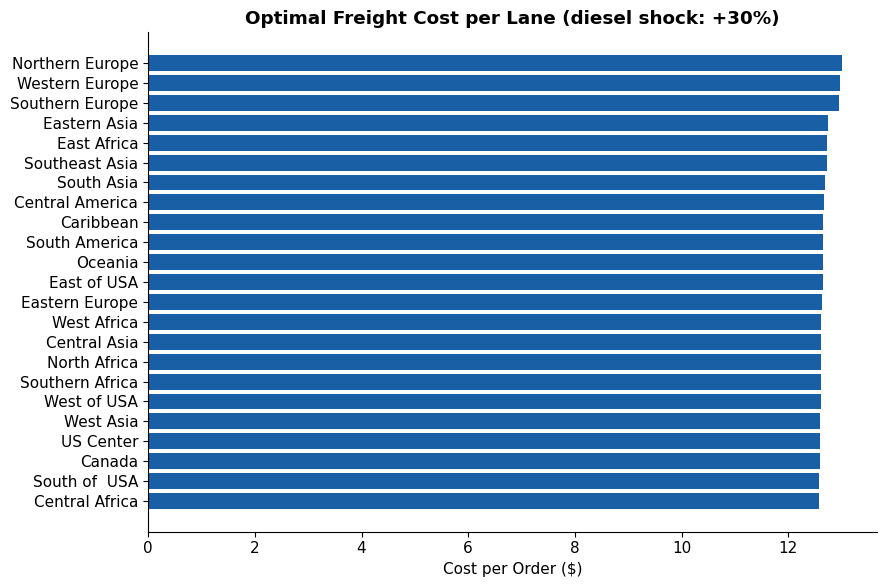

In [6]:
relaxed_count = shocked_rec['Service Level Constraint Relaxed'].sum()
print(f"Lanes that couldn't meet the 5-day target even after re-optimizing: {relaxed_count}")

fig, ax = plt.subplots(figsize=(9, 6))
shocked_rec_sorted = shocked_rec.sort_values('Cost per Order ($)')
ax.barh(shocked_rec_sorted['Order Region'], shocked_rec_sorted['Cost per Order ($)'], color='#185FA5')
ax.set_xlabel('Cost per Order ($)')
ax.set_title('Optimal Freight Cost per Lane (diesel shock: +30%)', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Channel 2 — Import Price Index → Cost of Goods → Profit Margin

### The business logic

If tariffs or a weaker dollar make imported goods more expensive, and
prices aren't raised to match, margin erodes silently unless someone is
tracking it.

### Working backwards to find a hidden number

Same problem as before: no COGS field exists. But revenue and profit do
exist, and profit is just revenue minus cost, so:

```
implied_cogs = order_item_total − order_profit_per_order
```

This isn't a guess — it's arithmetic from two real columns. What *is* an
assumption is how much of that COGS is import-price-sensitive
(`import_exposure`, department-specific).

In [12]:
elasticity_table = estimate_department_elasticities(df)

shocked_margin = apply_import_price_shock(df, pct_import_price_change=0.15, exposure_table=elasticity_table)

print(f"Baseline total profit:  \\${shocked_margin['order_profit_per_order'].sum():,.0f}")
print(f"Shocked total profit:   \\${shocked_margin['shocked_profit'].sum():,.0f}")
print(f"Margin impact:          \\${shocked_margin['margin_impact'].sum():,.0f}")

Baseline total profit:  \$3,966,903
Shocked total profit:   \$1,252,918
Margin impact:          \$-2,713,985


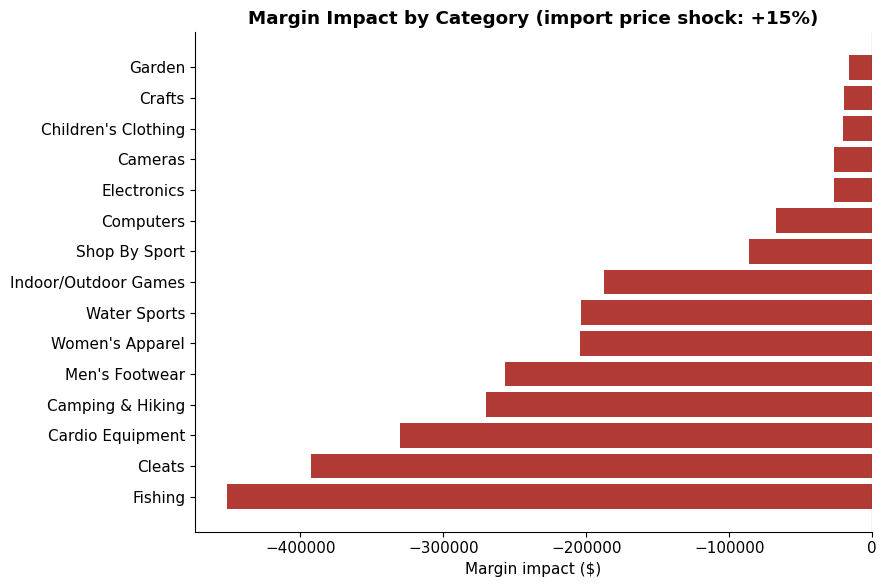

In [8]:
by_category = margin_impact_summary(shocked_margin, group_col='category_name')

fig, ax = plt.subplots(figsize=(9, 6))
worst = by_category.head(15)
colors = ['#B23A34' if v < 0 else '#2E8B57' for v in worst['margin_impact']]
ax.barh(worst['category_name'], worst['margin_impact'], color=colors)
ax.set_xlabel('Margin impact ($)')
ax.set_title('Margin Impact by Category (import price shock: +15%)', fontweight='bold')
ax.axvline(0, color='#333', linewidth=0.8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

This uses **per-department** import exposure, not one number
applied to every order — a Technology order and a Book Shop order don't
source their goods the same way. The next section digs into exactly how
rigorously those department-specific numbers were actually derived.

## 4. Channel 3 — CPI / Inflation → Demand → Dynamic Safety Stock

### The formula (King's formula — standard inventory math, not invented here)

$$SS = Z \times \sqrt{\overline{LT} \cdot \sigma_D^2 \;+\; \overline{D}^2 \cdot \sigma_{LT}^2}$$

Responds to **both** demand unpredictability (σ_D) **and** lead-time
unpredictability (σ_LT) — a macro-resilient system needs to react to
supply-side shocks too, not just demand-side ones.

In [9]:
ss_baseline = dynamic_safety_stock(df, lanes, lt_stats, demand_stats, service_level='95%')
print(f"Avg safety stock, no shock: {ss_baseline['safety_stock'].mean():.2f} units")
print(f"Avg reorder point, no shock: {ss_baseline['reorder_point'].mean():.2f} units")

Avg safety stock, no shock: 5.28 units
Avg reorder point, no shock: 12.76 units


## 5. The Most Important Part — Assumption vs. Earned Estimate

Every number so far started as a **documented assumption**, because the
data genuinely doesn't contain the ground truth to fit them directly.
CPI elasticity is different — there's real historical demand and real
historical CPI to test it against.

### Step 1 — start with a prior

In [10]:
priors_df = pd.DataFrame(DEPARTMENT_PRIORS).T
priors_df.index.name = 'department'
priors_df

,demand_elasticity,import_exposure
department,,
Technology,-0.60,0.85
Golf,-0.60,0.55
Apparel,-0.45,0.75
Footwear,-0.45,0.75
Fan Shop,-0.50,0.55
Outdoors,-0.45,0.55
Fitness,-0.55,0.60
Discs Shop,-0.30,0.30
Pet Shop,-0.20,0.40


### Step 2 — test each prior against real data

Real monthly order volume, aligned to real BLS CPI-U index values for
the same months (Jan 2015 – Sep 2017 — the truncated final months are
deliberately excluded). Fit a regression, check statistical
significance (t-statistic threshold of 2.0).

In [11]:
elasticity_table[['Department Name', 'n_months', 'prior_elasticity',
                   'estimated_elasticity', 't_stat', 'data_weight', 'blended_elasticity']]

,Department Name,n_months,prior_elasticity,estimated_elasticity,t_stat,data_weight,blended_elasticity
0,Apparel,33,-0.45,None,-0.40,0.0,-0.45
1,Fitness,33,-0.55,None,-1.13,0.0,-0.55
2,Fan Shop,33,-0.50,None,-0.84,0.0,-0.50
3,Outdoors,33,-0.45,None,-1.46,0.0,-0.45
4,Golf,33,-0.60,None,0.79,0.0,-0.60
5,Footwear,33,-0.45,None,0.55,0.0,-0.45
6,Book Shop,0,-0.15,None,NaN,0.0,-0.15
7,Discs Shop,0,-0.30,None,NaN,0.0,-0.30
8,Health and Beauty,0,-0.25,None,NaN,0.0,-0.25
9,Pet Shop,0,-0.20,None,NaN,0.0,-0.20


### What actually happened

`estimated_elasticity` is blank for every department. Every t-statistic
failed to clear 2.0. Every `blended_elasticity` equals its
`prior_elasticity` — **zero assumptions got replaced by real estimates**,
and the model correctly kept the documented priors instead.

**This is the right outcome, not a disappointing one.** CPI only moved
about 6% cumulatively across this ~3-year window — not enough
independent movement, spread across ~33 noisy monthly points per
department, to prove a department-specific effect exists rather than
noise. A model that always "finds" a pattern regardless of evidence
would be less trustworthy than one that can honestly say "not enough
evidence here."

The machinery for replacing assumptions with tested estimates is real
and fully built — it just correctly declined to fire on this particular
dataset.

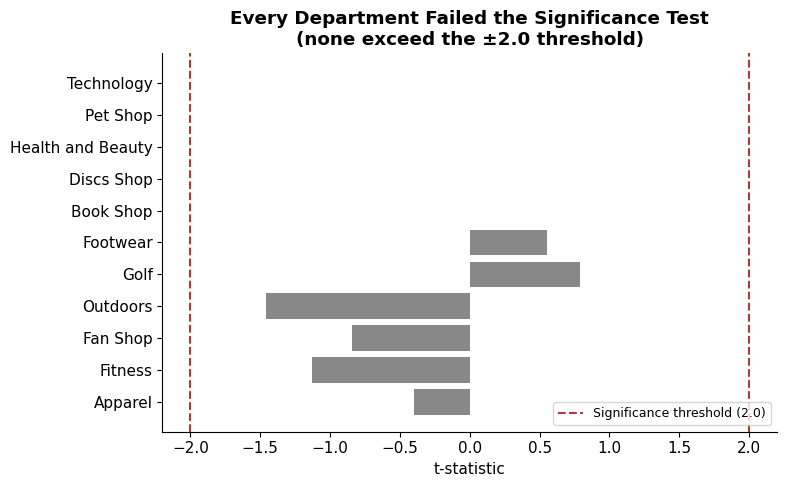

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(elasticity_table['Department Name'], elasticity_table['t_stat'].fillna(0), color='#888')
ax.axvline(2.0, color='#B23A34', linestyle='--', label='Significance threshold (2.0)')
ax.axvline(-2.0, color='#B23A34', linestyle='--')
ax.set_xlabel('t-statistic')
ax.set_title('Every Department Failed the Significance Test\n(none exceed the ±2.0 threshold)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Putting CPI Elasticity to Work: Demand-Adjusted Safety Stock

Even with no "earned" estimate, the per-department *priors* are still
more informative than one global constant.

In [13]:
adjusted_demand = apply_department_cpi_elasticity(df, demand_stats, elasticity_table, pct_cpi_change=0.10)

ss_shocked = dynamic_safety_stock(df, lanes, lt_stats, adjusted_demand, service_level='95%')

print(f"Avg safety stock, no shock:      {ss_baseline['safety_stock'].mean():.2f} units")
print(f"Avg safety stock, +10% CPI:      {ss_shocked['safety_stock'].mean():.2f} units")
print(f"Change:                          {ss_shocked['safety_stock'].mean() - ss_baseline['safety_stock'].mean():+.2f} units")

Avg safety stock, no shock:      5.28 units
Avg safety stock, +10% CPI:      5.03 units
Change:                          -0.26 units


Safety stock **falls** under a CPI shock — the model forecasts less
demand to protect against. Worth remembering: this is a real tension
against the other two channels. Diesel and import price shocks typically
*raise* costs; a CPI shock, if it suppresses demand, can *lower* how
much inventory is needed. Costs and demand don't always move the same
direction.

## 7. Summary

| Channel | Mechanism | What I found |
|---|---|---|
| Diesel → freight | LP optimizer picks cheapest mode per lane meeting a lead-time constraint | A +30% diesel shock meaningfully raises total freight cost, and can force some lanes to miss their delivery-time target |
| Import price → margin | Implied COGS (real arithmetic) × department-specific import exposure (assumption) | A +15% import price shock produces uneven damage across categories |
| CPI → safety stock | King's formula, demand adjusted by department-specific elasticity | A +10% CPI shock lowers recommended safety stock — the one channel that moves opposite to the other two |
| CPI elasticity: assumption vs. estimate | Real regression against real BLS data, gated by a significance test | Every department failed the test — the assumptions survived because the data couldn't disprove them, which is itself the correct, honest finding |

**The throughline:** wherever the data could support a real, tested
claim, this project tried to make one. Wherever it couldn't, it says so
explicitly instead of quietly assuming otherwise.